## Imports and paths

In [101]:
from pathlib import Path

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [102]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format','{:,.2f}'.format)

PROJECT_DIR = Path.cwd().parent

DATA_PATH = PROJECT_DIR / 'data' / 'processed' / 'real_estate_clean.csv'
FIGURES_PATH = PROJECT_DIR / 'reports' / 'figures'

DATA_PATH

WindowsPath('c:/Users/mikri/OneDrive/Desktop/real-estate-price-advisor/data/processed/real_estate_clean.csv')

## Load cleaned dataset

In [103]:
df = pd.read_csv(
    DATA_PATH,
    parse_dates=["published_at"],
    low_memory=False,
)

df.head()

,price,date,time,geo_lat,geo_lon,region,building_type,floor,floors,rooms,area,kitchen_area,object_type,published_at,publication_year,publication_quarter,publication_month
0,6050000,2018-02-19,20:00:21,59.81,30.38,2661,1,8,10,3,82.60,10.80,1,2018-02-19 20:00:21,2018,1,2
1,8650000,2018-02-27,12:04:54,55.68,37.30,81,3,5,24,2,69.10,12.00,1,2018-02-27 12:04:54,2018,1,2
2,4000000,2018-02-28,15:44:00,56.30,44.06,2871,1,5,9,3,66.00,10.00,1,2018-02-28 15:44:00,2018,1,2
3,1850000,2018-03-01,11:24:52,45.00,39.07,2843,4,12,16,2,38.00,5.00,11,2018-03-01 11:24:52,2018,1,3
4,5450000,2018-03-01,17:42:43,55.92,37.98,81,3,13,14,2,60.00,10.00,1,2018-03-01 17:42:43,2018,1,3


In [104]:
df.shape

(5470541, 17)

In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5470541 entries, 0 to 5470540
Data columns (total 17 columns):
 #   Column               Dtype         
---  ------               -----         
 0   price                int64         
 1   date                 str           
 2   time                 str           
 3   geo_lat              float64       
 4   geo_lon              float64       
 5   region               int64         
 6   building_type        int64         
 7   floor                int64         
 8   floors               int64         
 9   rooms                int64         
 10  area                 float64       
 11  kitchen_area         float64       
 12  object_type          int64         
 13  published_at         datetime64[us]
 14  publication_year     int64         
 15  publication_quarter  int64         
 16  publication_month    int64         
dtypes: datetime64[us](1), float64(4), int64(10), str(2)
memory usage: 709.5 MB


## Basic checks

In [106]:
df.describe()

,price,geo_lat,geo_lon,region,building_type,floor,floors,rooms,area,kitchen_area,object_type,published_at,publication_year,publication_quarter,publication_month
count,"5,470,541.00","5,470,541.00","5,470,541.00","5,470,541.00","5,470,541.00","5,470,541.00","5,470,541.00","5,470,541.00","5,470,541.00","5,470,541.00","5,470,541.00",5470541,"5,470,541.00","5,470,541.00","5,470,541.00"
mean,"4,537,035.41",54.04,53.24,"4,306.98",1.95,6.21,11.40,1.73,53.93,10.60,3.94,2019-11-21 07:51:48.627982,"2,019.38",2.53,6.63
min,1.00,41.46,19.89,3.00,0.00,1.00,1.00,-1.00,0.22,0.01,1.00,2018-02-19 20:00:21,"2,018.00",1.00,1.00
25%,"1,950,000.00",53.38,37.78,"2,661.00",1.00,2.00,5.00,1.00,38.00,7.00,1.00,2019-03-14 18:08:25,"2,019.00",1.00,3.00
50%,"2,990,000.00",55.17,43.07,"2,922.00",2.00,5.00,10.00,2.00,48.02,9.70,1.00,2019-10-14 06:20:33,"2,019.00",3.00,7.00
75%,"4,807,840.00",56.23,65.65,"6,171.00",3.00,9.00,16.00,2.00,63.13,12.70,11.00,2020-07-18 15:06:47,"2,020.00",4.00,10.00
max,"2,147,483,647.00",71.98,162.54,"61,888.00",5.00,39.00,39.00,10.00,"7,856.00","4,949.00",11.00,2021-05-01 20:14:15,"2,021.00",4.00,12.00
std,"15,519,251.07",4.62,20.74,"3,307.86",1.04,4.96,6.54,1.08,33.29,6.04,4.56,NaN,0.87,1.16,3.54


In [107]:
df.isna().sum().sort_values(ascending=False)

price                  0
date                   0
time                   0
geo_lat                0
geo_lon                0
region                 0
building_type          0
floor                  0
floors                 0
rooms                  0
area                   0
kitchen_area           0
object_type            0
published_at           0
publication_year       0
publication_quarter    0
publication_month      0
dtype: int64

In [108]:
df.duplicated().sum()

np.int64(0)

## EDA DF preparing

In [109]:
df_eda = df.copy()

df_eda["log_price"] = np.log1p(df_eda["price"])
df_eda["log_area"] = np.log1p(df_eda["area"])
df_eda["price_per_m2"] = df_eda["price"] / df_eda["area"]

df_eda.head()

,price,date,time,geo_lat,geo_lon,region,building_type,floor,floors,rooms,area,kitchen_area,object_type,published_at,publication_year,publication_quarter,publication_month,log_price,log_area,price_per_m2
0,6050000,2018-02-19,20:00:21,59.81,30.38,2661,1,8,10,3,82.60,10.80,1,2018-02-19 20:00:21,2018,1,2,15.62,4.43,"73,244.55"
1,8650000,2018-02-27,12:04:54,55.68,37.30,81,3,5,24,2,69.10,12.00,1,2018-02-27 12:04:54,2018,1,2,15.97,4.25,"125,180.90"
2,4000000,2018-02-28,15:44:00,56.30,44.06,2871,1,5,9,3,66.00,10.00,1,2018-02-28 15:44:00,2018,1,2,15.20,4.20,"60,606.06"
3,1850000,2018-03-01,11:24:52,45.00,39.07,2843,4,12,16,2,38.00,5.00,11,2018-03-01 11:24:52,2018,1,3,14.43,3.66,"48,684.21"
4,5450000,2018-03-01,17:42:43,55.92,37.98,81,3,13,14,2,60.00,10.00,1,2018-03-01 17:42:43,2018,1,3,15.51,4.11,"90,833.33"


## Target distribution: price

In [110]:
price_quantiles = df_eda["price"].quantile([0.01, 0.05, 0.5, 0.95, 0.99, 0.999])
price_quantiles

0.01      750,000.00
0.05    1,150,000.00
0.50    2,990,000.00
0.95   11,386,935.00
0.99   24,050,000.00
1.00   86,640,284.60
Name: price, dtype: float64

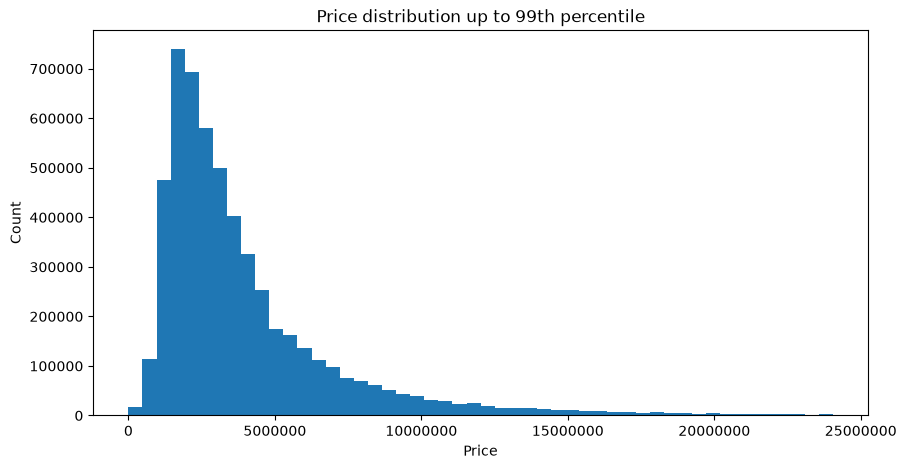

In [111]:
price_p99 = df_eda["price"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(df_eda.loc[df_eda["price"] <= price_p99, "price"], bins=50)
plt.title("Price distribution up to 99th percentile")
plt.xlabel("Price")
plt.ylabel("Count")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

In [142]:
PRICE_DISTRIBUTION_PATH = FIGURES_PATH / "price_distribution.png"

plt.savefig(PRICE_DISTRIBUTION_PATH, dpi=300, bbox_inches="tight")

print("Saved figure:", PRICE_DISTRIBUTION_PATH)

Saved figure: c:\Users\mikri\OneDrive\Desktop\real-estate-price-advisor\reports\figures\price_distribution.png


<Figure size 640x480 with 0 Axes>

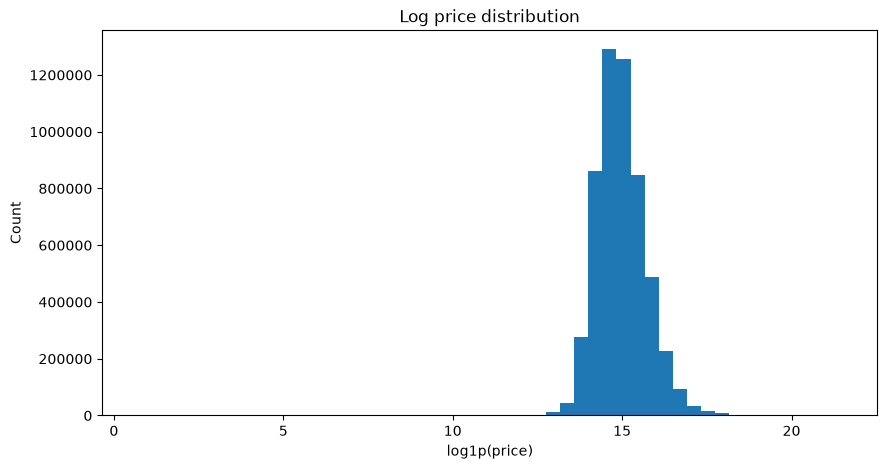

In [137]:
plt.figure(figsize=(10, 5))
plt.hist(df_eda["log_price"], bins=50)
plt.title("Log price distribution")
plt.xlabel("log1p(price)")
plt.ylabel("Count")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

## Area distribution

In [113]:
area_quantiles = df_eda["area"].quantile([0.01, 0.05, 0.5, 0.95, 0.99, 0.999])
area_quantiles

0.01    19.80
0.05    29.00
0.50    48.02
0.95    93.00
0.99   138.10
1.00   294.00
Name: area, dtype: float64

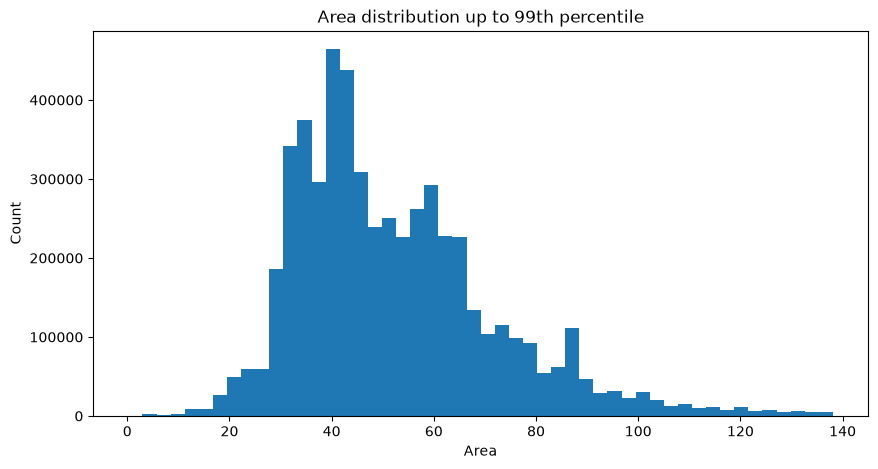

In [114]:
area_p99 = df_eda["area"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(df_eda.loc[df_eda["area"] <= area_p99, "area"], bins=50)
plt.title("Area distribution up to 99th percentile")
plt.xlabel("Area")
plt.ylabel("Count")
plt.show()

## Rooms distribution

In [115]:
rooms_counts = df_eda["rooms"].value_counts().sort_index()
rooms_counts

rooms
-1      305883
 1     2064857
 2     1825266
 3     1096083
 4      152053
 5       22563
 6        2356
 7         788
 8         353
 9         338
 10          1
Name: count, dtype: int64

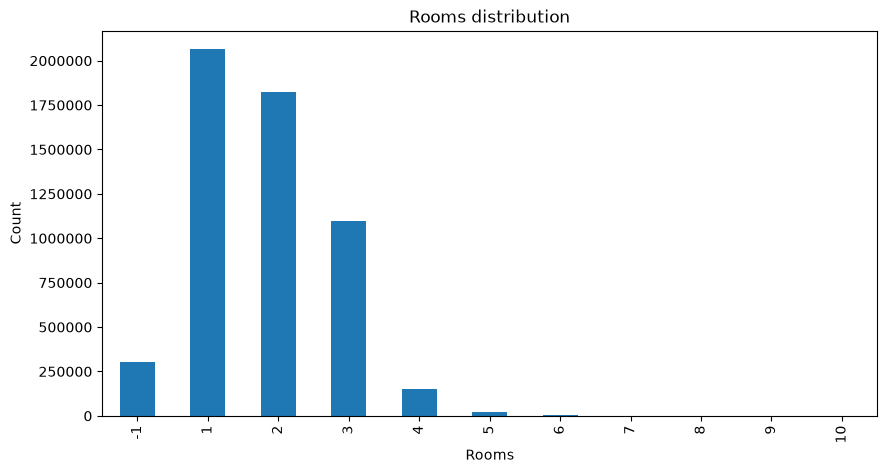

In [138]:
plt.figure(figsize=(10, 5))
rooms_counts.plot(kind="bar")
plt.title("Rooms distribution")
plt.xlabel("Rooms")
plt.ylabel("Count")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

## Price by rooms

In [117]:
price_by_rooms = (
    df_eda
    .groupby("rooms")["price"]
    .agg(["count", "median", "mean"])
    .sort_index()
)

price_by_rooms

,count,median,mean
rooms,,,
-1,305883,"1,890,000.00","3,423,447.02"
1,2064857,"2,300,000.00","3,049,992.70"
2,1825266,"3,300,000.00","4,516,834.69"
3,1096083,"4,150,000.00","6,226,292.26"
4,152053,"5,234,500.00","10,806,066.48"
5,22563,"11,760,000.00","25,857,710.13"
6,2356,"19,000,000.00","45,111,875.02"
7,788,"21,000,000.00","51,039,361.19"
8,353,"23,500,000.00","47,699,330.99"


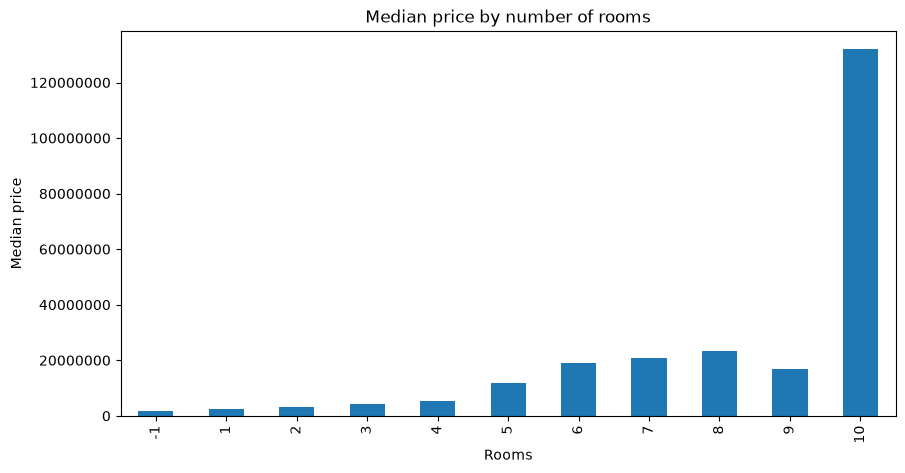

In [118]:
plt.figure(figsize=(10, 5))
price_by_rooms["median"].plot(kind="bar")
plt.title("Median price by number of rooms")
plt.xlabel("Rooms")
plt.ylabel("Median price")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

## Price vs Area

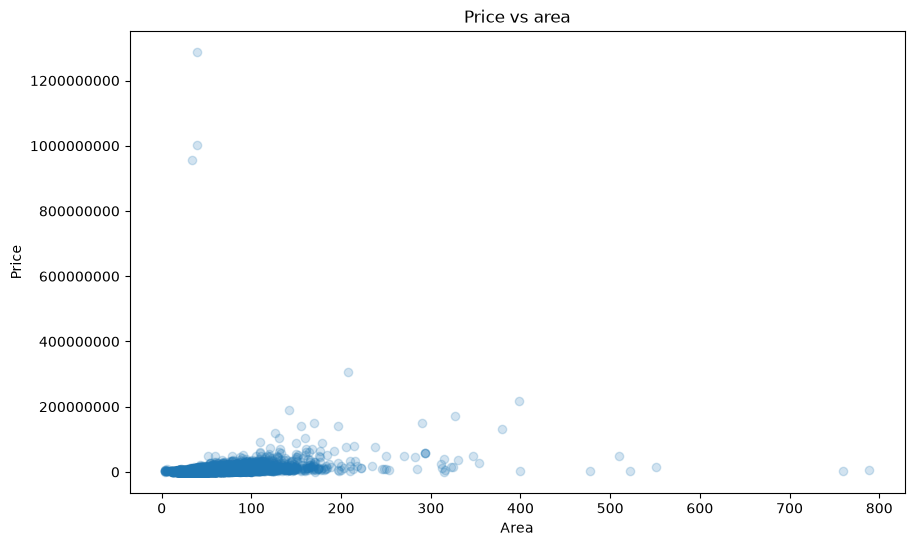

In [119]:
sample_size = min(20_000, df_eda.shape[0])
df_sample = df_eda.sample(sample_size, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(df_sample["area"], df_sample["price"], alpha=0.2)
plt.title("Price vs area")
plt.xlabel("Area")
plt.ylabel("Price")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

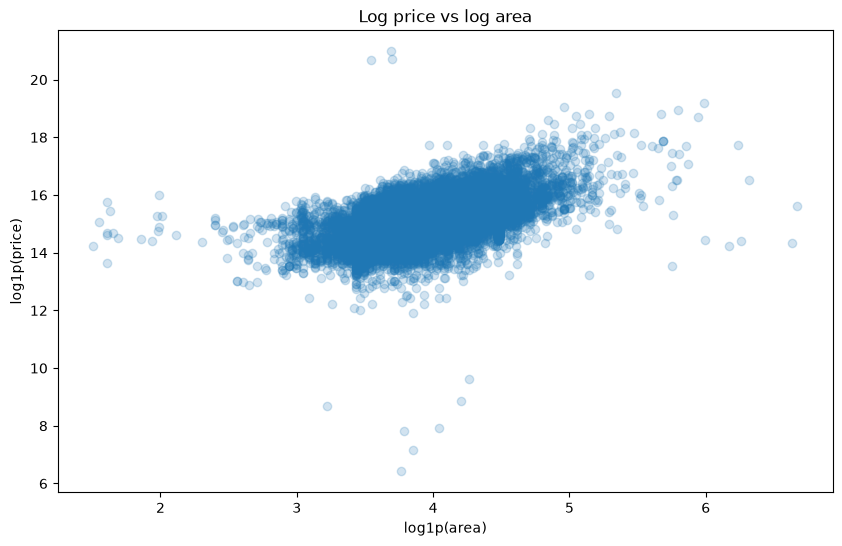

In [120]:
plt.figure(figsize=(10, 6))
plt.scatter(df_sample["log_area"], df_sample["log_price"], alpha=0.2)
plt.title("Log price vs log area")
plt.xlabel("log1p(area)")
plt.ylabel("log1p(price)")
plt.show()

In [144]:
LOG_PRICE_VS_LOG_AREA_PATH = FIGURES_PATH / "log_price_vs_log_area.png"

plt.savefig(LOG_PRICE_VS_LOG_AREA_PATH, dpi=300, bbox_inches="tight")

print("Saved figure:", LOG_PRICE_VS_LOG_AREA_PATH)

Saved figure: c:\Users\mikri\OneDrive\Desktop\real-estate-price-advisor\reports\figures\log_price_vs_log_area.png


<Figure size 640x480 with 0 Axes>

## Price per square meter

In [121]:
price_m2_quantiles = df_eda["price_per_m2"].quantile([0.01, 0.05, 0.5, 0.95, 0.99, 0.999])
price_m2_quantiles

0.01    18,072.29
0.05    27,691.96
0.50    61,000.00
0.95   191,891.89
0.99   303,278.69
1.00   673,913.04
Name: price_per_m2, dtype: float64

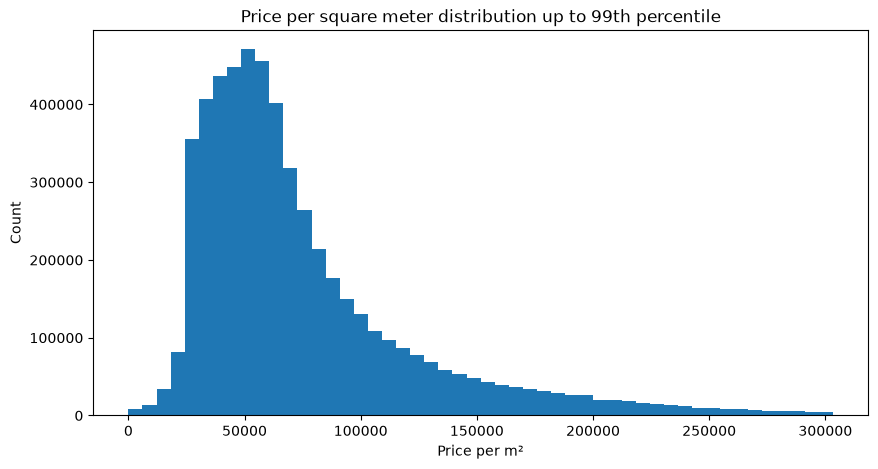

In [122]:
price_m2_p99 = df_eda["price_per_m2"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(df_eda.loc[df_eda["price_per_m2"] <= price_m2_p99, "price_per_m2"], bins=50)
plt.title("Price per square meter distribution up to 99th percentile")
plt.xlabel("Price per m²")
plt.ylabel("Count")
plt.show()

## Floor features

In [123]:
floor_stats = df_eda[["floor", "floors"]].describe()
floor_stats

,floor,floors
count,"5,470,541.00","5,470,541.00"
mean,6.21,11.40
std,4.96,6.54
min,1.00,1.00
25%,2.00,5.00
50%,5.00,10.00
75%,9.00,16.00
max,39.00,39.00


In [124]:
df_eda["floor_ratio"] = df_eda["floor"] / df_eda["floors"]
df_eda["is_first_floor"] = (df_eda["floor"] == 1).astype(int)
df_eda["is_last_floor"] = (df_eda["floor"] == df_eda["floors"]).astype(int)

In [139]:
floor_price = pd.DataFrame({
    "first_floor_median": [df_eda.loc[df_eda["is_first_floor"] == 1, "price"].median()],
    "last_floor_median": [df_eda.loc[df_eda["is_last_floor"] == 1, "price"].median()],
    "other_floor_median": [df_eda.loc[(df_eda["is_first_floor"] == 0) & (df_eda["is_last_floor"] == 0), "price"].median()],
})

floor_price

,first_floor_median,last_floor_median,other_floor_median
0,"2,250,000.00","2,400,000.00","3,250,000.00"


## Region analysis

In [126]:
region_counts = df_eda["region"].value_counts()

region_counts.head(20)

region
9654    1048363
2843     636504
81       499847
2661     461303
3        438906
6171     236941
2922     230264
3230     222377
5282     155495
3991     141552
2604     104627
2871     101022
2722      86636
3870      83374
3106      80238
6817      74134
2072      63095
2900      58978
3019      56369
3446      52796
Name: count, dtype: int64

In [127]:
top_regions = region_counts.head(15).index

region_price = (
    df_eda[df_eda["region"].isin(top_regions)]
    .groupby("region")["price"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)

region_price

,count,median,mean
region,,,
3,438906,"9,350,000.00","13,136,595.38"
2661,461303,"5,950,000.00","8,244,124.56"
81,499847,"4,300,000.00","4,766,509.69"
3991,141552,"3,350,000.00","3,828,112.73"
2922,230264,"3,206,000.00","3,627,156.12"
6171,236941,"2,958,000.00","3,402,731.83"
2871,101022,"2,900,000.00","3,624,743.56"
2843,636504,"2,800,000.00","3,586,537.50"
3870,83374,"2,790,000.00","3,139,132.56"


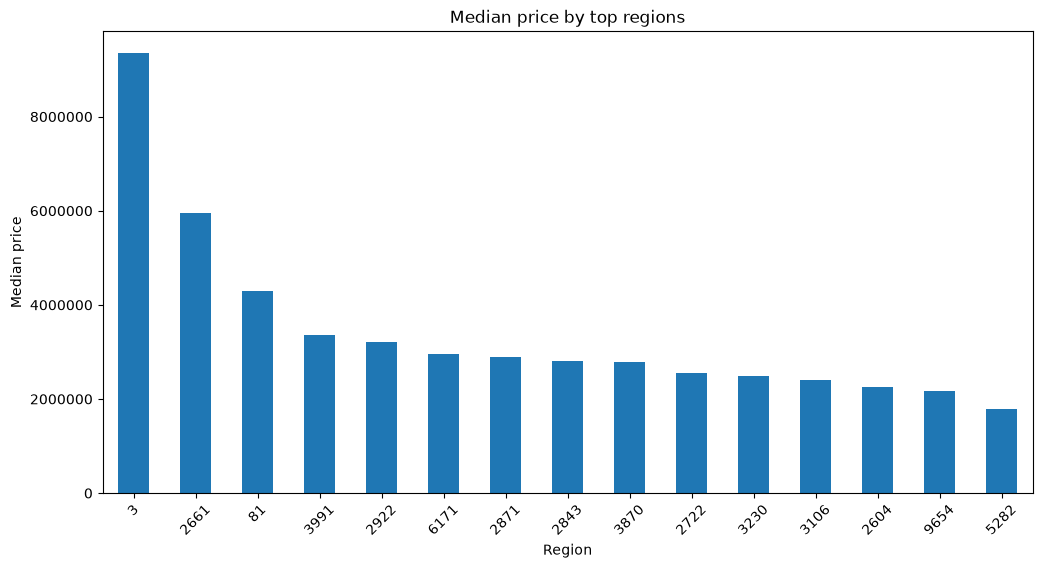

In [128]:
plt.figure(figsize=(12, 6))
region_price["median"].plot(kind="bar")
plt.title("Median price by top regions")
plt.xlabel("Region")
plt.ylabel("Median price")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis='y')
plt.show()

## Object type analysis

In [129]:
object_type_counts = df_eda["object_type"].value_counts(dropna=False).sort_index()
object_type_counts

object_type
1     3859527
11    1611014
Name: count, dtype: int64

In [130]:
object_type_price = (
    df_eda
    .groupby("object_type")["price"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)

object_type_price

,count,median,mean
object_type,,,
11,1611014,"3,100,000.00","4,959,263.98"
1,3859527,"2,950,000.00","4,360,792.02"


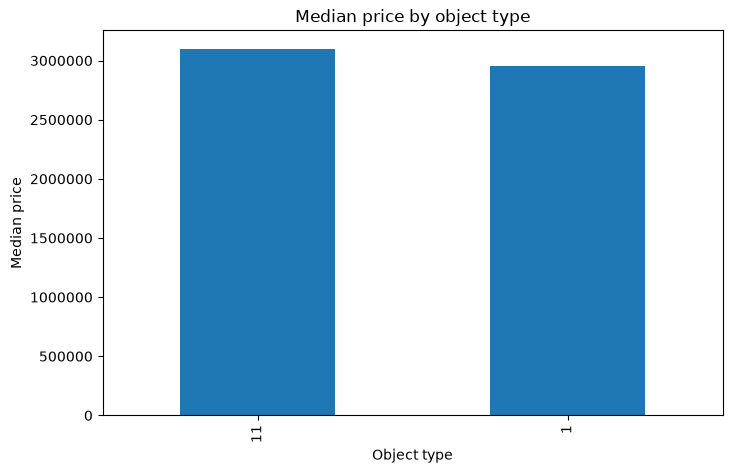

In [131]:
plt.figure(figsize=(8, 5))
object_type_price["median"].plot(kind="bar")
plt.title("Median price by object type")
plt.xlabel("Object type")
plt.ylabel("Median price")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

## Building type analysis

In [132]:
building_type_counts = df_eda["building_type"].value_counts(dropna=False).sort_index()
building_type_counts

building_type
0     306929
1    1953360
2    1129698
3    1890040
4     174215
5      16299
Name: count, dtype: int64

In [133]:
building_type_price = (
    df_eda
    .groupby("building_type")["price"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)

building_type_price

,count,median,mean
building_type,,,
2,1129698,"4,620,000.00","7,092,411.42"
0,306929,"3,750,000.00","5,263,165.27"
3,1890040,"2,820,000.00","4,048,952.19"
4,174215,"2,700,000.00","3,996,207.81"
1,1953360,"2,400,000.00","3,481,788.52"
5,16299,"1,200,000.00","2,593,400.84"


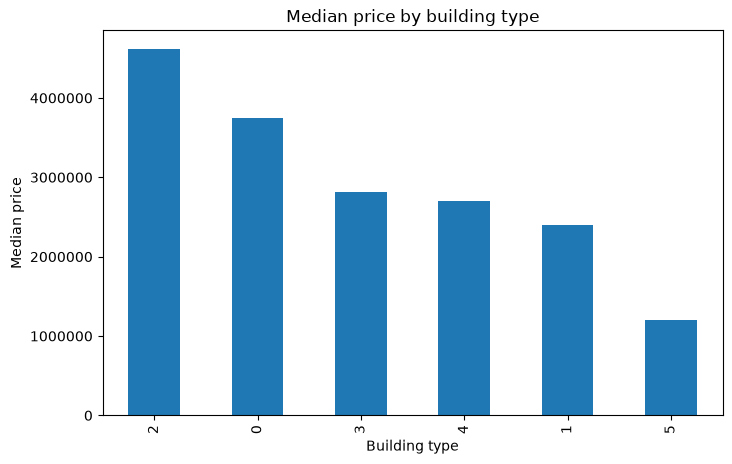

In [134]:
plt.figure(figsize=(8, 5))
building_type_price["median"].plot(kind="bar")
plt.title("Median price by building type")
plt.xlabel("Building type")
plt.ylabel("Median price")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

## Numeric correlation

In [135]:
numeric_columns = [
    "price",
    "log_price",
    "area",
    "log_area",
    "kitchen_area",
    "rooms",
    "floor",
    "floors",
    "floor_ratio",
    "geo_lat",
    "geo_lon",
]

existing_numeric_columns = [
    column for column in numeric_columns
    if column in df_eda.columns
]

corr = df_eda[existing_numeric_columns].corr(numeric_only=True)

corr["price"].sort_values(ascending=False)

price           1.00
log_price       0.36
log_area        0.17
area            0.17
kitchen_area    0.14
rooms           0.11
floors          0.07
floor           0.06
geo_lat         0.05
floor_ratio     0.00
geo_lon        -0.08
Name: price, dtype: float64

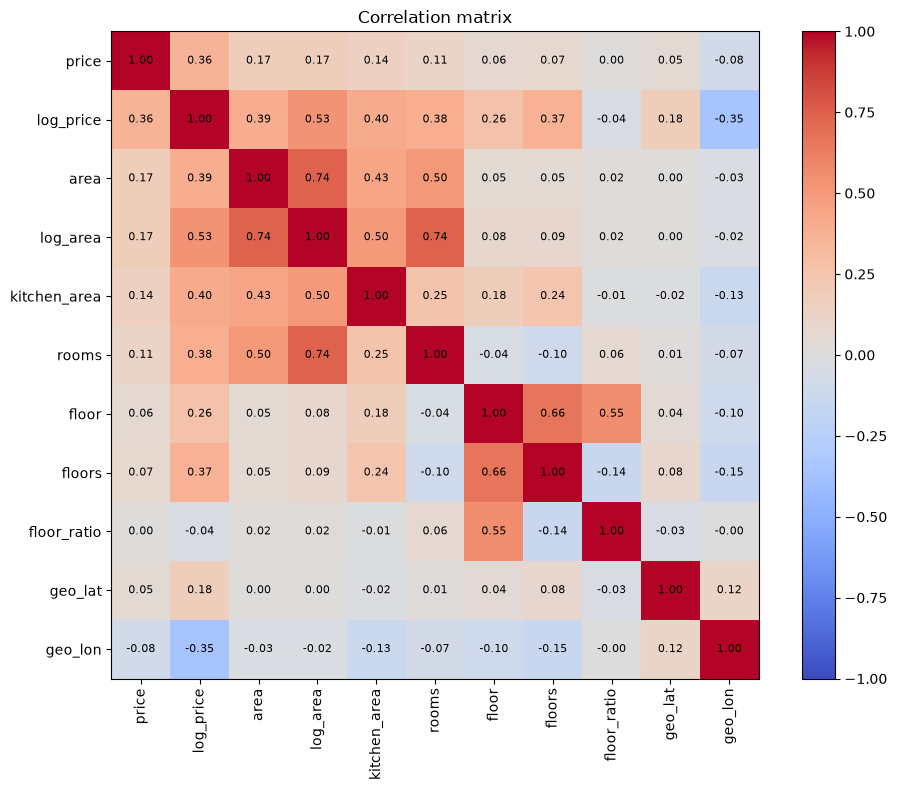

In [140]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
ax.set_title("Correlation matrix")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

In [141]:
CORRELATION_FIGURE_PATH = FIGURES_PATH / "correlation_matrix.png"

plt.savefig(
    CORRELATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Candidate features for modeling

    "area",
    "rooms",
    "floor",
    "floors",
    "kitchen_area",
    "geo_lat",
    "geo_lon",
    "region",
    "building_type",
    "object_type",
    "floor_ratio",
    "is_first_floor",
    "is_last_floor",
    "publication_year",
    "publication_month",
    "publication_quarter",

## Features to exclude

    "price",
    "log_price",
    "price_per_m2",
    "date",
    "time",
    "published_at",